In [1]:
import sys
sys.path.insert(0, '/home/gmottier/COM-304-FM/nano4M-extension/nano4M')

In [2]:
import os
import imageio
from IPython.display import Image as IPImage, display
import numpy as np
from PIL import Image

In [3]:
def make_canny_circle(cx, cy, r, size=256, thickness=1):
    img = np.zeros((size, size), dtype=np.uint8)
    Y, X = np.ogrid[:size, :size]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = (dist >= r - thickness) & (dist <= r + thickness)
    img[mask] = 255
    return Image.fromarray(img)

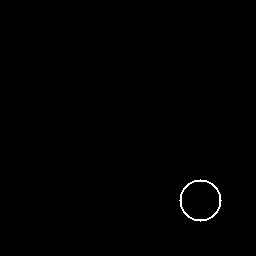

In [4]:
img = make_canny_circle(200, 200, 20)
display(img)

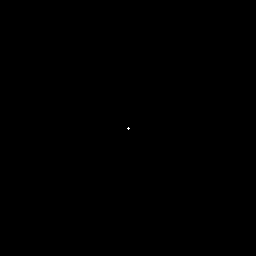

In [5]:
os.makedirs('assets/growing_circle_frames', exist_ok=True)
os.makedirs('assets/gifs', exist_ok=True)

frames = []
for i in range(15):
    img = make_canny_circle(128, 128, 5 * i)
    img.save(f'assets/growing_circle_frames/frame_{i:02d}.png')
    frames.append(img)

gif_path = 'assets/gifs/circle_grow.gif'
imageio.mimsave(gif_path, frames, duration=0.15, loop=0)

display(IPImage(gif_path))

In [6]:
waypoints = [(50, 50), (200, 50), (200, 200), (50, 200), (50, 50)]
n_frames = 60

In [7]:
def interpolate_square(waypoints, n_frames):
    points = []
    n_segments = len(waypoints) - 1
    frames_per_segment = n_frames // n_segments
    for i in range(n_segments):
        x0, y0 = waypoints[i]
        x1, y1 = waypoints[i + 1]
        for t in np.linspace(0, 1, frames_per_segment, endpoint=False):
            points.append((int(x0 + t * (x1 - x0)), int(y0 + t * (y1 - y0))))
    return points

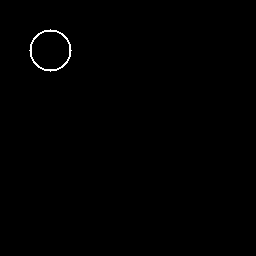

In [8]:
frames = []

os.makedirs('assets/moving_circle_frames', exist_ok=True)

for cx, cy in interpolate_square(waypoints, n_frames):
    img = make_canny_circle(cx, cy, 20)
    img.save(f'assets/moving_circle_frames/frame_{len(frames):03d}.png')
    frames.append(img)

gif_path = 'assets/gifs/circle_move.gif'
imageio.mimsave(gif_path, frames, duration=0.15, loop=0)

display(IPImage(gif_path))

In [9]:
def make_canny_square(cx, cy, half_size, size=256, thickness=0.9):
    img = np.zeros((size, size), dtype=np.uint8)
    Y, X = np.ogrid[:size, :size]
    dist = np.maximum(np.abs(X - cx), np.abs(Y - cy))
    mask = (dist >= half_size - thickness) & (dist <= half_size + thickness)
    img[mask] = 255
    return Image.fromarray(img)

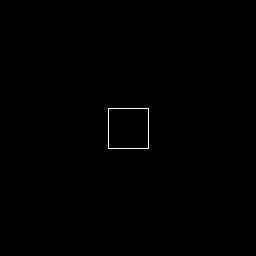

In [10]:
img = make_canny_square(128, 128, 20)
display(img)

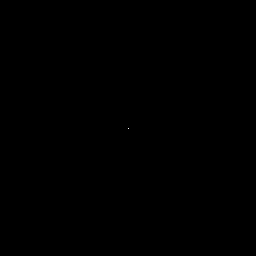

In [11]:
os.makedirs('assets/growing_square_frames', exist_ok=True)

frames = []
for i in range(15):
    img = make_canny_square(128, 128, 5 * i)
    img.save(f'assets/growing_square_frames/frame_{i:02d}.png')
    frames.append(img)

gif_path = 'assets/gifs/square_grow.gif'
imageio.mimsave(gif_path, frames, duration=0.15, loop=0)

display(IPImage(gif_path))

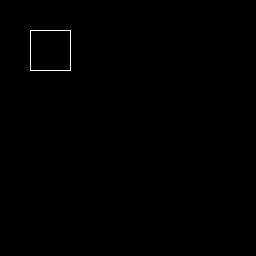

In [12]:
frames = []

os.makedirs('assets/moving_square_frames', exist_ok=True)

for cx, cy in interpolate_square(waypoints, n_frames):
    img = make_canny_square(cx, cy, 20)
    img.save(f'assets/moving_square_frames/frame_{len(frames):03d}.png')
    frames.append(img)

gif_path = 'assets/gifs/square_move.gif'
imageio.mimsave(gif_path, frames, duration=0.15, loop=0)

display(IPImage(gif_path))

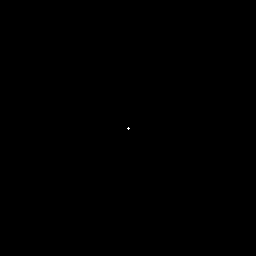

In [13]:
import os
import glob
import imageio
from PIL import Image

folders = [
    'assets/growing_circle_frames',
    'assets/moving_circle_frames',
    'assets/moving_square_frames',
    'assets/growing_square_frames',
]

os.makedirs('assets/stacked_frames', exist_ok=True)

all_frames = []
for folder in folders:
    paths = sorted(glob.glob(f'{folder}/*.png'))
    all_frames.extend(paths)

frames = []
for i, path in enumerate(all_frames):
    img = Image.open(path)
    img.save(f'assets/stacked_frames/frame_{i:04d}.png')
    frames.append(img)

imageio.mimsave('assets/gifs/all_shapes.gif', frames, duration=0.3, loop=0)
display(IPImage('assets/gifs/all_shapes.gif'))

In [14]:
from fourm.vq.vqvae import DiVAE
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

device = 'cuda' if torch.cuda.is_available() else 'cpu'

tok_edge_fourm = DiVAE.from_pretrained('EPFL-VILAB/4M_tokenizers_edge_8k_224-512').eval().to(device)

/home/gmottier/.local/lib/python3.10/site-packages/fourm/vq/quantizers/quantize_lucid.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/gmottier/.local/lib/python3.10/site-packages/fourm/vq/quantizers/quantize_lucid.py:388: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


xFormers not available
xFormers not available


In [15]:
TARGET_SIZE = 256

def tokenize_canny_4m(img: Image.Image):
    edges = np.array(img.resize((TARGET_SIZE, TARGET_SIZE))).astype(np.float32) / 255.0
    edges = edges * 2.0 - 1.0
    edges_tensor = torch.tensor(edges).unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, 256, 256)

    with torch.no_grad():
        tokens = tok_edge_fourm.tokenize(edges_tensor)
    return tokens

def decode_tokens_4m(tokens):
    with torch.no_grad():
        reconst = tok_edge_fourm.decode_tokens(tokens, image_size=TARGET_SIZE)
    img = reconst[0].squeeze(0).clamp(-1, 1)
    img = (img + 1) / 2
    return img.cpu().numpy()

/home/gmottier/.local/lib/python3.10/site-packages/fourm/vq/models/vit_models.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled = False):


Tokens shape: torch.Size([1, 16, 16])


/home/gmottier/.local/lib/python3.10/site-packages/fourm/vq/scheduling/diffusion_pipeline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Reconstruction shape: (256, 256)


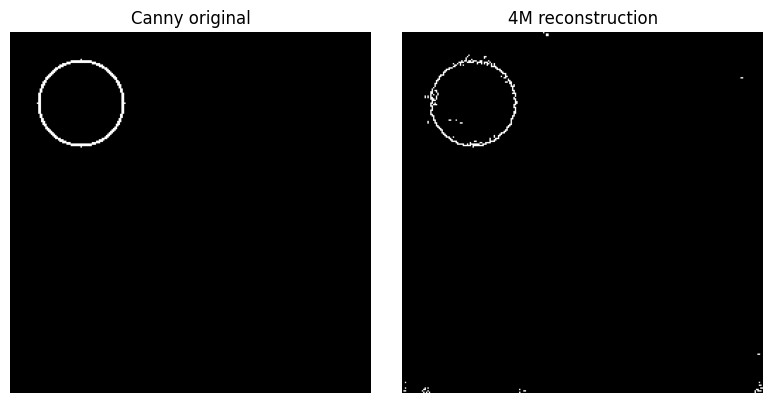

In [16]:
import matplotlib.pyplot as plt
img_test = make_canny_circle(50, 50, 30)

tokens = tokenize_canny_4m(img_test)
print(f"Tokens shape: {tokens.shape}")

img_np = decode_tokens_4m(tokens)
print(f"Reconstruction shape: {img_np.shape}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.array(img_test), cmap='gray')
axes[0].set_title('Canny original')
axes[0].axis('off')
axes[1].imshow(img_np, cmap='gray')
axes[1].set_title('4M reconstruction')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [17]:
import os
import glob
import torch
from PIL import Image

os.makedirs('assets/tokenized/stacked', exist_ok=True)

all_paths = sorted(glob.glob('assets/stacked_frames/*.png'))

for path in all_paths:
    img = Image.open(path).convert('L')
    tokens = tokenize_canny_4m(img)
    
    frame_name = os.path.splitext(os.path.basename(path))[0]
    torch.save(tokens, f'assets/tokenized/stacked/{frame_name}.pt')

print(f"Tokenized {len(all_paths)} frames")

Tokenized 150 frames


In [18]:
from nanofm.utils.checkpoint import load_model_from_safetensors

ckpt_path = '/scratch/tmaillar/outputs/nano4M/multiclevr_d6-6w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

44.322304M parameters


In [20]:
from cosmos_tokenizer.image_lib import ImageTokenizer
import math

image_tokenizer = ImageTokenizer(
    checkpoint_enc='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16/encoder.jit',
    checkpoint_dec='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16/decoder.jit',
).to(device)


In [21]:
def token_ids_to_image(token_ids, image_tokenizer, to_pil=False):
    n_tokens = token_ids.numel()
    side = int(math.sqrt(n_tokens))
    token_ids = token_ids.reshape(1,side,side).to(device)
    reconst = image_tokenizer.decode(token_ids)
    reconst = (reconst[0].clamp(-1,1).float().cpu() + 1) / 2
    if to_pil:
        reconst = TF.to_pil_image(reconst)
    return reconst

In [24]:
import torchvision.transforms.functional as TF
from IPython.display import clear_output

os.makedirs('assets/generated_rgb', exist_ok=True)

modalities=["tok_rgb@256", "tok_depth@256", "tok_normal@256", "scene_desc", "tok_canny@256"]
token_paths = sorted(glob.glob('assets/tokenized/stacked/*.pt'))

num_steps = 8
temp      = 0.1
top_p     = 0.2
top_k     = 0.0

for path in token_paths:
    frame_name = os.path.splitext(os.path.basename(path))[0]

    # Charger les tokens Canny
    canny_tokens = torch.load(path).to(device)

    enc_input_tokens = canny_tokens.reshape(1, -1)  # (1, 256)
    n_tokens = enc_input_tokens.shape[1]
    enc_input_positions  = torch.arange(n_tokens, device=device).unsqueeze(0)
    enc_input_modalities = modalities.index('tok_canny@256') * torch.ones(1, n_tokens, device=device, dtype=torch.long)

    # Générer le RGB
    pred_tokens, _, _, _ = model.generate_one_modality_roar(
        enc_input_tokens, enc_input_positions, enc_input_modalities,
        target_mod='tok_rgb@256',
        num_steps=num_steps,
        temp=temp,
        top_p=top_p,
        top_k=top_k,
    )

    # Décoder et sauvegarder
    rgb_img = token_ids_to_image(pred_tokens, image_tokenizer, to_pil=True)
    rgb_img.save(f'assets/generated_rgb/{frame_name}.png')
    
    clear_output(wait=True)
    print(f'Generated {frame_name} ({token_paths.index(path)+1}/{len(token_paths)})')

print('Done!')

Generated frame_0149 (150/150)
Done!


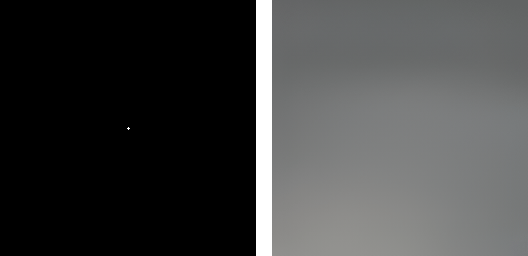

In [26]:
from PIL import Image
import imageio
import glob
import numpy as np

canny_paths = sorted(glob.glob('assets/stacked_frames/*.png'))
rgb_paths   = sorted(glob.glob('assets/generated_rgb/*.png'))

frames = []
for cp, rp in zip(canny_paths, rgb_paths):
    canny = Image.open(cp).convert('RGB').resize((256, 256))
    rgb   = Image.open(rp).convert('RGB').resize((256, 256))
    
    combined = Image.new('RGB', (512 + 16, 256), (255, 255, 255))
    combined.paste(canny, (0, 0))
    combined.paste(rgb, (256 + 16, 0))
    frames.append(combined)

imageio.mimsave('assets/gifs/comparison.gif', frames, duration=0.3, loop=0)
display(IPImage('assets/gifs/comparison.gif'))